In [1]:
import warnings
import numpy as np
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
from scipy.special import sph_harm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import matplotlib.cm as cm
from colorsys import hls_to_rgb

warnings.filterwarnings(
    "ignore",
    message="`scipy.special.sph_harm` is deprecated*",  # match SciPy's exact message
    category=DeprecationWarning
)

Data generation for this multitask setup

In [2]:
def generate_single_circle(normal, pts, m):
        n = normal / np.linalg.norm(normal)
        v1 = np.array([1., 0., 0.]) if abs(n[0]) < 0.9 else np.array([0., 1., 0.])
        v1 = v1 - n * np.dot(n, v1)
        v1 /= np.linalg.norm(v1)
        v2 = np.cross(n, v1)
        phi = np.linspace(0, 2*np.pi, pts, endpoint=False)
        X = np.outer(np.cos(phi), v1) + np.outer(np.sin(phi), v2)
        y = np.sin(m * phi)
        return X, y

def generate_multi_great_circle_tasks(
    K_tasks=2,
    pts_per_circle=512,
    m=4,
    ):

    # Choose evenly spaced normals to define great circles
    theta_norm = np.linspace(0, np.pi, K_tasks, endpoint=False)
    phi_norm   = np.linspace(0, 2*np.pi, K_tasks, endpoint=False)

    normals = np.stack([
        np.sin(theta_norm) * np.cos(phi_norm),
        np.sin(theta_norm) * np.sin(phi_norm),
        np.cos(theta_norm)
    ], axis=1)

    X_train_list, y_list, task_slices = [], [], []
    start = 0

    for j, n in enumerate(normals):

        # Generate data for the circle
        X, labels = generate_single_circle(n, pts_per_circle, m)

        # Store
        X_train_list.append(X)
        y_list.append(labels)
        task_slices.append(slice(start, start + pts_per_circle))
        start += pts_per_circle

    X_train = np.vstack(X_train_list)
    y_train = np.concatenate(y_list)

    return X_train, y_train, task_slices

def run_ntk_multi_great_circle(
    K_tasks=2,
    pts_per_circle=512,
    m=4,
    W_std=1.0,
    b_std=1.0,
    reg_scale=1e-5,
    trainable=("W","b"),
):
    """
    NTK multitask on K great-circle tasks with fixed degree m.
    Stores per-task test predictions and geometry for plotting.
    """

    # Get training set
    X_train_np, y_train_np, task_slices_train = generate_multi_great_circle_tasks(
        K_tasks=K_tasks,
        pts_per_circle=pts_per_circle,
        m=m
    )

    # Get test set
    X_test_np, y_test_np, task_slices_test = generate_multi_great_circle_tasks(
        K_tasks=K_tasks,
        pts_per_circle=2 * pts_per_circle,
        m=m
    )

    X_train = jnp.array(X_train_np, dtype=jnp.float32)
    y_train = jnp.array(y_train_np, dtype=jnp.float32)
    X_test  = jnp.array(X_test_np,  dtype=jnp.float32)
    y_test  = jnp.array(y_test_np,  dtype=jnp.float32)

    # Define model and get kernel
    _, _, kernel_fn = stax.serial(
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable),
        stax.Relu(),
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable),
    )
    kernel_fn = nt.batch(kernel_fn, device_count=-1)

    # Compute kernels
    K_train = jnp.array(kernel_fn(X_train, X_train, "ntk"))
    K_test_train = jnp.array(kernel_fn(X_test, X_train, "ntk"))

    # Compute eigenspectrum of the kernel
    eigvals = jnp.linalg.eigvalsh(K_train)

    # Compute the regularized kernel with relative regularization
    reg = float(jnp.max(eigvals)) * reg_scale
    K_reg = K_train + reg * jnp.eye(len(K_train))

    # Solve and get predictions
    alpha = jnp.linalg.solve(K_reg, y_train)
    y_pred_test = K_test_train @ alpha

    # Store performance per-task
    task_results = []
    mse_test_per_task = []

    for sl in task_slices_test:
        yt = np.array(y_test_np[sl])
        yp = np.array(y_pred_test[sl])
        mse = float(np.mean((yt - yp)**2))

        task_results.append(dict(y_true=yt, y_pred=yp))
        mse_test_per_task.append(mse)

    return dict(
        K_tasks=K_tasks,
        pts_per_circle=pts_per_circle,
        m=m,
        reg=reg,
        eigvals=np.array(eigvals),
        mse_per_task=mse_test_per_task,
        tasks=task_results,
    )

def run_single_circle_ntk_task(normal, pts_per_circle=512, m=4, reg_scale=1e-5):
    
    """
    If we were to run the previous code for K=1 it would be impossible to 
    get results for different orientations of the circle, this function
    solves that problem.
    """

    # Generate circle data according to normal
    X_train_np, y_train_np = generate_single_circle(normal, pts_per_circle, m)
    X_test_np, y_test_np = generate_single_circle(normal, pts_per_circle * 2, m)

    X_train = jnp.array(X_train_np, dtype=jnp.float32)
    y_train = jnp.array(y_train_np, dtype=jnp.float32)
    X_test  = jnp.array(X_test_np,  dtype=jnp.float32)
    y_test  = jnp.array(y_test_np,  dtype=jnp.float32)

    # Get kernel from model
    _, _, kernel_fn = stax.serial(
        stax.Dense(1, W_std=1.0, b_std=1.0, parameterization="ntk"),
        stax.Relu(),
        stax.Dense(1, W_std=1.0, b_std=1.0, parameterization="ntk"),
    )
    kernel_fn = nt.batch(kernel_fn)

    # Compute kernel
    K_train = kernel_fn(X_train, X_train, "ntk")
    K_test_train = kernel_fn(X_test, X_train, "ntk")

    # Compute eigenspectrum
    eigvals = jnp.linalg.eigvalsh(K_train)

    # Compute regularized kernel, with relative regularization
    reg = float(jnp.max(eigvals)) * reg_scale
    K_reg = K_train + reg * jnp.eye(len(K_train))

    # Solve and get predictions
    alpha = jnp.linalg.solve(K_reg, y_train)
    y_pred = K_test_train @ alpha
    mse = float(jnp.mean((y_test - y_pred)**2))

    return dict(
        mse=mse,
        eigvals=np.array(eigvals),
        y_true=np.array(y_test_np),
        y_pred=np.array(y_pred),
    )

Let's define the visulization functions

In [10]:
def plot_great_circles_3d(X, y, task_slices, elev=25, azim=25, cmap="viridis"):
    
    """
    Plot training data of different-circle harmonics on the sphere
    """

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot circles
    for sl in task_slices:
        ax.scatter(X[sl,0], X[sl,1], X[sl,2],
                             c=y[sl], cmap=cmap,
                             s=25, alpha=0.95)

    # Sphere grid
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.15, linewidth=0.5)

    ax.set_title("Great-Circle Tasks on the sphere")
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1,1,1))
    ax.set_axis_off()
    plt.show()

def plot_circle_harmonics(y, task_slices, m, cmap=cm.viridis):

    """
    Show all the harmonics, each just considering its own circle
    """

    plt.figure(figsize=(10,4))  # slightly wider for legend space

    K = len(task_slices)
    colors = cmap(np.linspace(0, 1, K, endpoint=False))

    for i, sl in enumerate(task_slices):
        N = sl.stop - sl.start
        phi = np.linspace(0, 2*np.pi, N, endpoint=False)
        plt.plot(phi, y[sl], lw=2, label=f"Task {i+1}", color=colors[i])

    plt.xlabel("theta")
    plt.ylabel(f"sin({m}theta)")
    plt.title(f"Circular Harmonic (m = {m})")
    plt.grid(True, alpha=0.4)

    # Legend outside to the right
    plt.legend(
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0.,
        ncol=max(1, K // 10)
    )

    plt.tight_layout()
    plt.show()

def plot_multi_circle_avg_performance(results,
                                      single_task_results=None,
                                      single_task_label="Single-task (rotated circles)"):

    """
    Plot multi-task NTK performance (avg test MSE vs #tasks).
    Optionally overlay single-task experiment (each task trained independently).
    """

    plt.figure(figsize=(8,5))

    # Multi-task experiment
    Ks = [res['K_tasks'] for res in results]
    mean_mse = [jnp.mean(jnp.array(res['mse_per_task'])) for res in results]

    plt.semilogy(Ks, mean_mse, 'o-', lw=2, label="Multi-task NTK")

    # Baseline line
    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    # Optional overlay: Single-task worst-case geometry
    if single_task_results is not None:
        mse_vals = [r['mse'] for r in single_task_results]
        task_ids = np.arange(len(mse_vals))
        plt.semilogy(task_ids+1, mse_vals, 'o-', lw=1.5, c="black",
                     label=single_task_label)

    # Axes formatting
    plt.xlabel("Number of Tasks")
    plt.ylabel("Avg Test MSE (log)")
    plt.title("NTK Multi-Task Capacity on the sphere")
    plt.grid(True, which='both')

    plt.tight_layout()
    plt.legend()
    plt.show()

def plot_multi_circle_worst_performance(results,
                                        single_task_results=None,
                                        single_task_label="Single-task (rotated circles)"):

    """
    Plot multi-task NTK worst-case performance (max test MSE per task vs #tasks).
    Optionally overlay single-task experiment (each circle trained independently).
    """

    plt.figure(figsize=(8,5))

    # Multi-task experiment
    Ks = [res['K_tasks'] for res in results]
    worst_mse = [jnp.max(jnp.array(res['mse_per_task'])) for res in results]

    plt.semilogy(Ks, worst_mse, 'o-', lw=2, label="Multi-task NTK (worst per task)")

    # Baseline
    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    # Optional: overlay single-task rotated-circle experiment
    if single_task_results is not None:
        mse_vals = [r['mse'] for r in single_task_results]
        task_ids = np.arange(len(mse_vals))
        plt.semilogy(task_ids+1, mse_vals, 'o-', lw=1.5, c="black",
                     label=single_task_label)

    # Formatting
    plt.xlabel("Number of Tasks")
    plt.ylabel("Worst Test MSE (log)")
    plt.title("Worst-Case NTK Multi-Task Capacity on the sphere")
    plt.grid(True, which='both')

    plt.tight_layout()
    plt.legend()
    plt.show()


def plot_per_task_mse(results, show_legend=True, cmap="viridis"):
    
    """
    On a series of multitask kernel regressions for different number of tasks,
    plot a curve for each K_tasks setup, where the points are the single task
    mse for the multitask kernel (meaning the performance of the multitask kernel
    on the points of each task singularly). 
    """
    
    plt.figure(figsize=(8,5))

    cm = plt.colormaps.get_cmap(cmap)
    K_results = len(results)

    for i, res in enumerate(results):
        K = res['K_tasks']
        mses = res['mse_per_task']

        # Sample evenly from colormap
        color = cm(i / max(1, K_results - 1))
        
        plt.plot(range(1, K+1), mses, 'o-', label=f"K={K}", color=color)

    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    plt.xlabel("Task index")
    plt.ylabel("Test MSE per task")
    plt.yscale("log")
    plt.title("Task Interference Structure")
    plt.grid(True, alpha=0.4)
    if show_legend:
        ncol=max(1,len(results)//6)
        plt.legend(ncol=ncol)
    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_sorted_task_mse(results, show_legend=True, cmap="viridis"):

    """
    On a series of multitask kernel regressions for different number of tasks,
    plot a curve for each K_tasks setup, where the points are the single task
    mse for the multitask kernel (meaning the performance of the multitask kernel
    on the points of each task singularly). The points are sorted by mse.
    """

    plt.figure(figsize=(8,5))

    cm = plt.colormaps.get_cmap(cmap)
    K_results = len(results)

    for i, res in enumerate(results):
        K = res['K_tasks']
        sorted_mses = sorted(res["mse_per_task"])

        # Sample evenly from colormap
        color = cm(i / max(1, K_results - 1))

        plt.semilogy(range(1, K+1), sorted_mses, 'o-', label=f"K={K}", color=color)

    plt.axhline(y=0.5, label="Const 0 pred", c="red", linestyle="--")

    plt.xlabel("Tasks sorted by MSE")
    plt.ylabel("Test MSE")
    plt.title("Multi-Task Capacity (sorted)")
    plt.grid(True, alpha=0.4)

    if show_legend:
        ncol = max(1, K_results // 6)
        plt.legend(ncol=ncol)

    plt.tight_layout()
    plt.show()

def plot_true_vs_pred(idx, normals, configs, results, cmap="viridis"):
    
    # Retrieve task info
    normal = normals[idx]
    pts = configs[idx]['pts_per_circle'] * 2  # Use test resolution
    m = configs[idx]['m']
    res = results[idx]

    # Generate 3D test geometry
    X = generate_single_circle(normal, pts, m)[0]

    y_true = res["y_true"]
    y_pred = res["y_pred"]

    fig = plt.figure(figsize=(12, 5))

    # Left, true labels
    ax1 = fig.add_subplot(121, projection='3d')
    sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2],
                      c=y_true, cmap=cmap, s=20)
    ax1.set_title(f"True — Circle {idx}")
    fig.colorbar(sc1, ax=ax1, label="True sin(m theta)")
    ax1.set_box_aspect([1,1,1])
    ax1.view_init(elev=20, azim=45)

    # Right, predicted labels
    ax2 = fig.add_subplot(122, projection='3d')
    sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2],
                      c=y_pred, cmap=cmap, s=20)
    ax2.set_title(f"Predicted — Circle {idx}")
    fig.colorbar(sc2, ax=ax2, label="Pred sin(m theta)")
    ax2.set_box_aspect([1,1,1])
    ax2.view_init(elev=20, azim=45)

    plt.suptitle(f"Orientation {idx} — normal={normal.round(3)}")
    plt.tight_layout()
    plt.show()

Show an example of the tasks

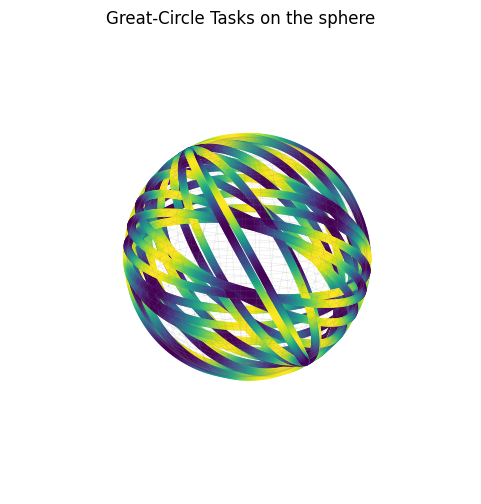

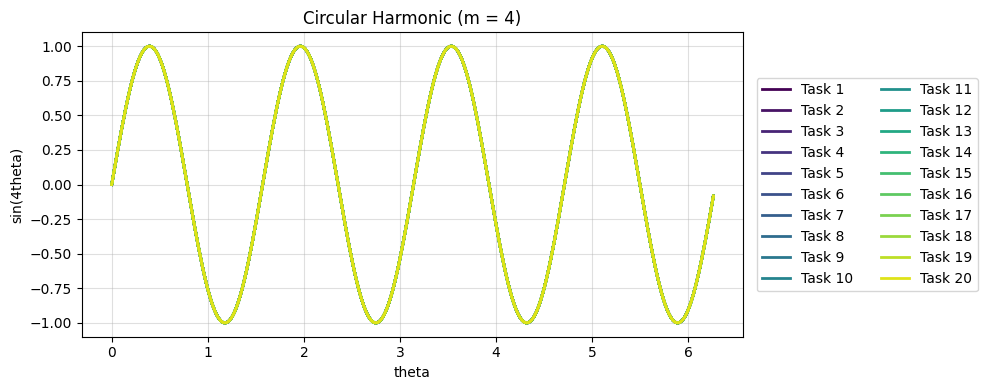

In [4]:
K = 20 # Number of tasks 
m = 4  # Degree of each harmonic

X_train, y_train, slices = generate_multi_great_circle_tasks(
    K_tasks=K, pts_per_circle=300, m=m
)

plot_great_circles_3d(X_train, y_train, slices)
plot_circle_harmonics(y_train, slices, m)

Use harmonic of degree 4 because it's the first non-trivial one that can be learned in all cases (full ntk no bias, full ntk with bias, bias only ntk). We first have to check that, however we orient the great circle, the ntk can learn the 4th degree harmonic on it.

In [5]:
num_tasks = 90
m = 4
pts_per_circle = 512
reg_scale = 1e-5

# Generate normals for great circles
theta_norm = np.linspace(0, np.pi, num_tasks, endpoint=False)
phi_norm = np.linspace(0, 2 * np.pi, num_tasks, endpoint=False)
normals = np.stack([
    np.sin(theta_norm) * np.cos(phi_norm),
    np.sin(theta_norm) * np.sin(phi_norm),
    np.cos(theta_norm)
], axis=1)

configs = []

for j in range(num_tasks):
    configs.append(dict(
        normal=normals[j],
        pts_per_circle=pts_per_circle,
        m=m,
        reg_scale=reg_scale
    ))

results_single = []

for cfg in tqdm(configs, desc="Running single-task sin(4φ) NTK regressions"):
    results_single.append(run_single_circle_ntk_task(**cfg))

Running single-task sin(4φ) NTK regressions: 100%|██████████| 90/90 [00:23<00:00,  3.91it/s]


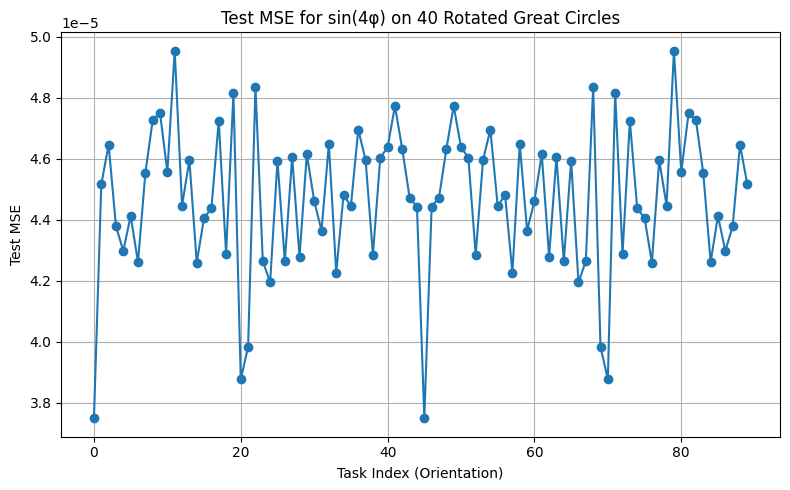

In [6]:
mse_vals = [r["mse"] for r in results_single]

plt.figure(figsize=(8,5))
plt.plot(range(num_tasks), mse_vals, marker='o')
plt.title("Test MSE for sin(4φ) on 40 Rotated Great Circles")
plt.xlabel("Task Index (Orientation)")
plt.ylabel("Test MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

Make sure that the results are correct by plotting

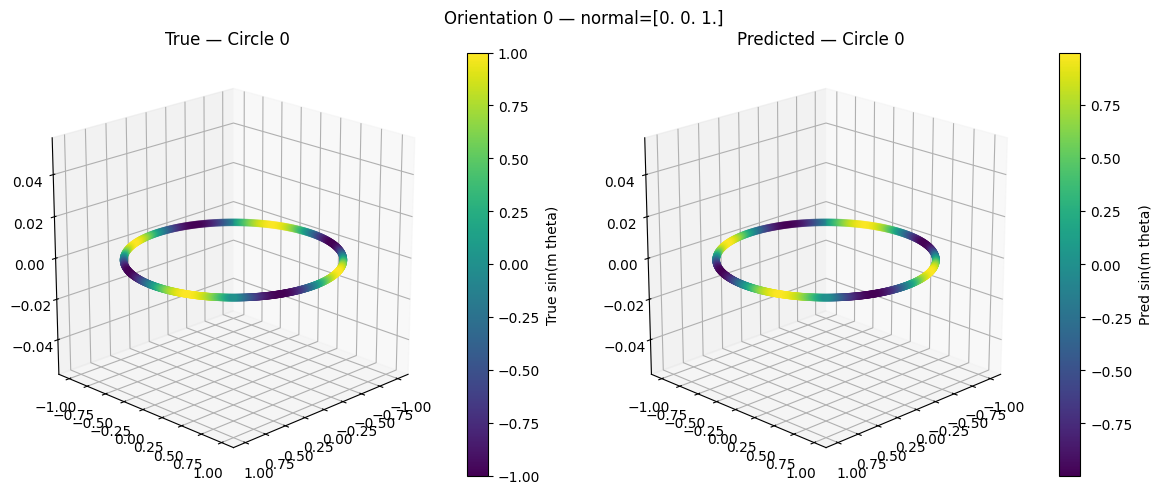

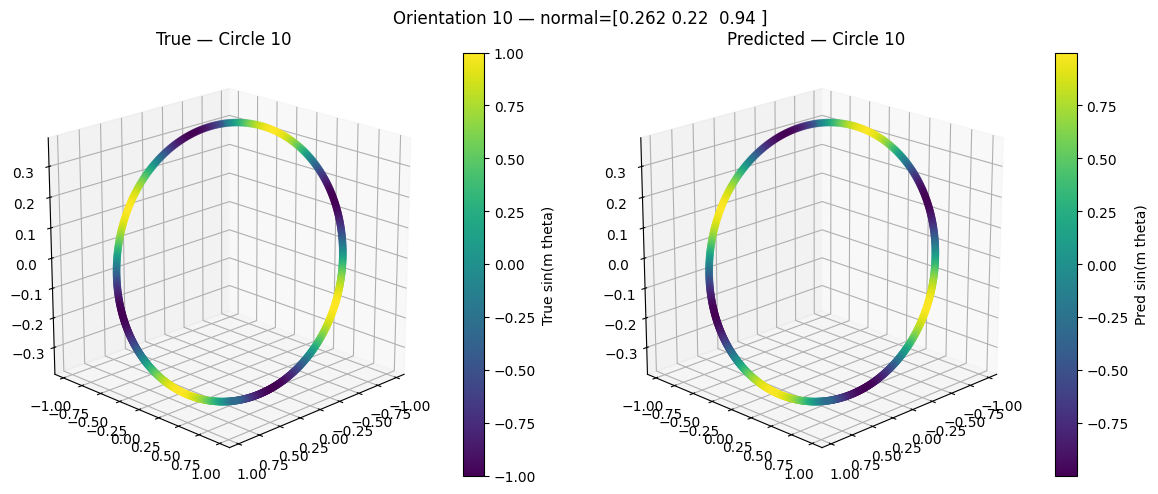

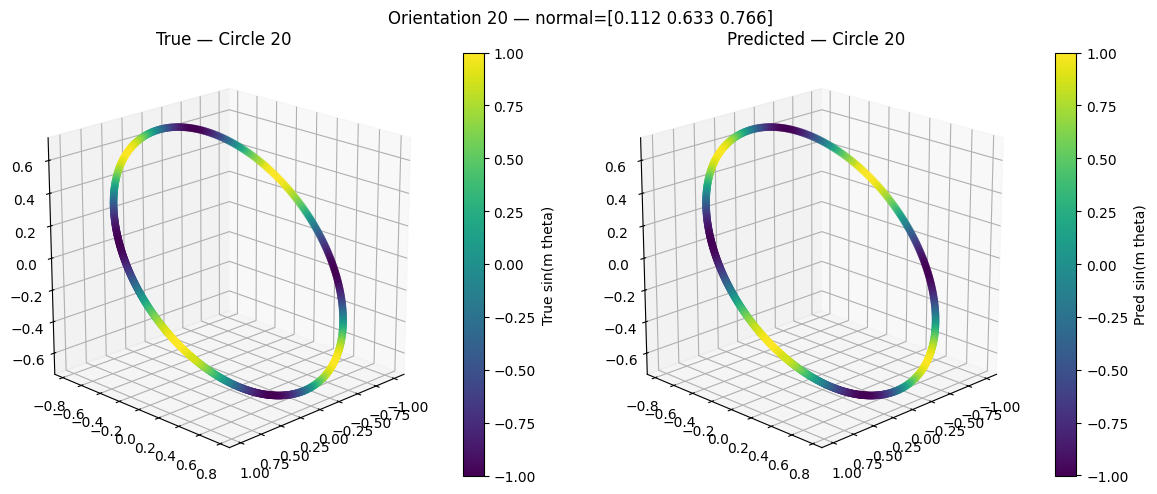

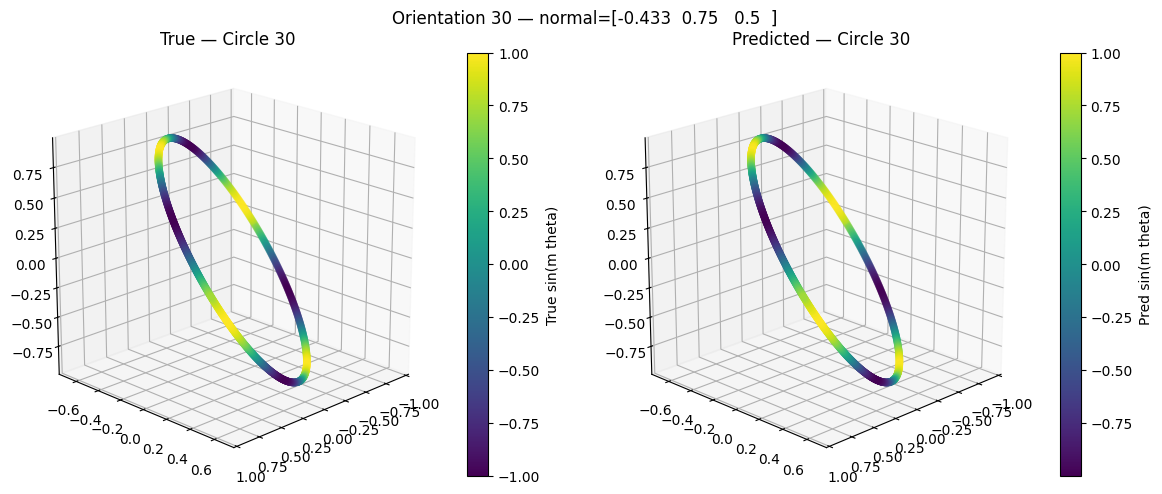

In [7]:
example_ids = [0, 10, 20, 30]
for idx in example_ids:
    plot_true_vs_pred(idx, normals, configs, results_single)

Now we can see what happens if we need to learn multiple at the same time.

In [8]:
configs = []
results_multi = []
m = 4

for K in [1,2,3,4,5,10,15,20,25,30,35,40,45,50,55,60,65,70,65,70,75,80,85,90]:
    configs.append(dict(K_tasks=K, pts_per_circle=256, m=m, reg_scale=1e-5))

for cfg in tqdm(configs):
    results_multi.append(run_ntk_multi_great_circle(**cfg))

100%|██████████| 24/24 [02:26<00:00,  6.09s/it]


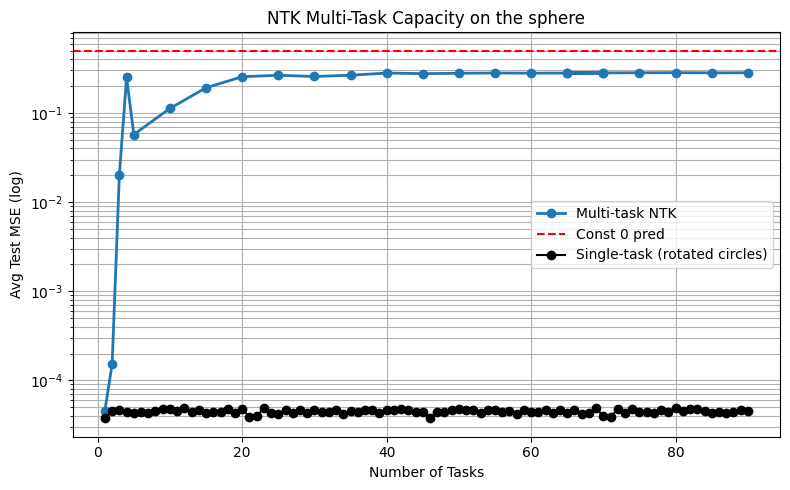

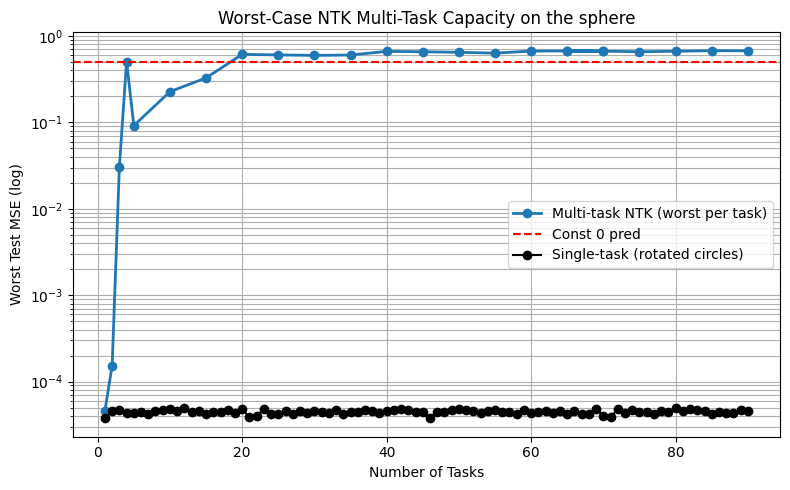

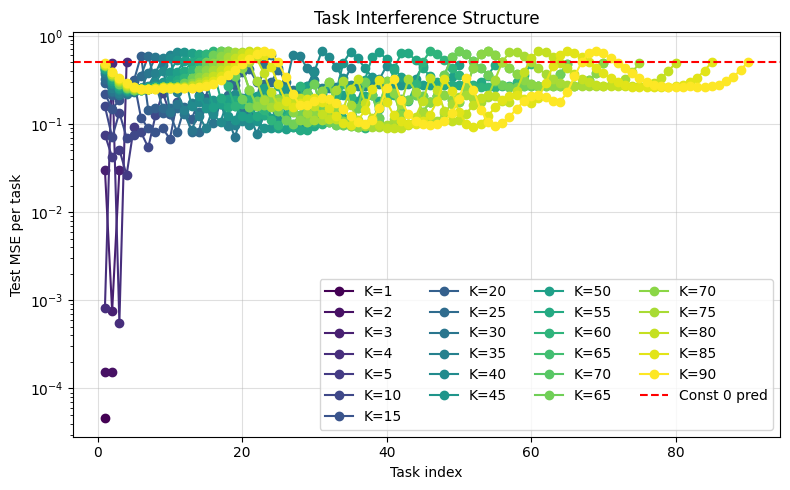

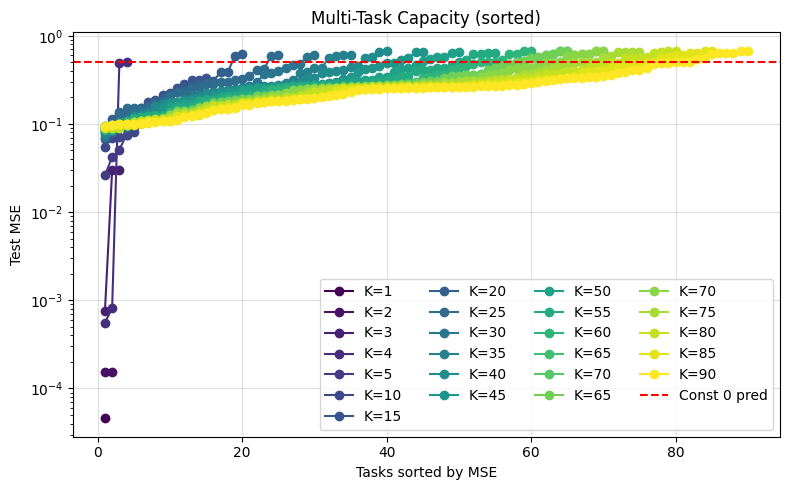

In [9]:
plot_multi_circle_avg_performance(results_multi,
                                  single_task_results=results_single)
plot_multi_circle_worst_performance(results_multi,
                                    single_task_results=results_single)
plot_per_task_mse(results_multi)
plot_sorted_task_mse(results_multi)